In [2]:
import numpy as np
import matplotlib.pyplot as plt
import hoomd

def measure_pair_potential(
    pair_force,
    r_values,
    box_length=30,
    particle_type="A",
    seed=1,
):
    """
    Measure pair potential energy U(r) for two particles using a HOOMD pair force.
    """

    energies = []

    for r in r_values:
        # ----------------------------
        # Two-particle snapshot
        # ----------------------------
        snap = hoomd.Snapshot()
        snap.particles.N = 2
        snap.particles.types = [particle_type]
        snap.particles.typeid[:] = [0, 0]

        snap.configuration.box = [box_length, box_length, box_length, 0, 0, 0]

        snap.particles.position[:] = [
            [-r / 2, 0, 0],
            [ r / 2, 0, 0],
        ]

        # ----------------------------
        # Small temporary simulation
        # ----------------------------
        sim_test = hoomd.Simulation(
            device=hoomd.device.CPU(),
            seed=seed,
        )

        sim_test.create_state_from_snapshot(snap)

        integrator = hoomd.md.Integrator(dt=0.005)
        integrator.forces.append(pair_force)
        sim_test.operations.integrator = integrator

        thermo = hoomd.md.compute.ThermodynamicQuantities(
            filter=hoomd.filter.All()
        )
        sim_test.operations.computes.append(thermo)

        sim_test.run(0)

        energies.append(thermo.potential_energy)

    return np.array(energies)

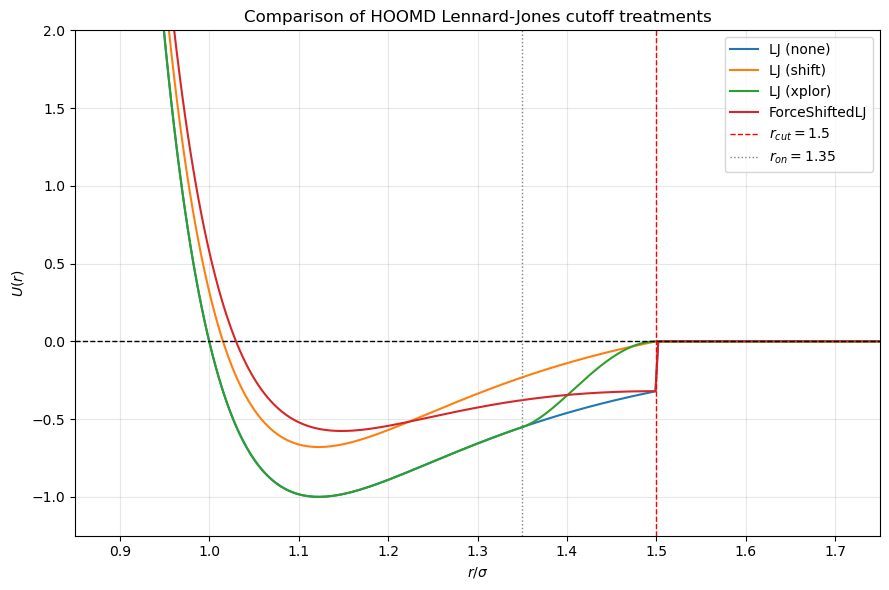

Saved: /home/pnichols/MDsims/Plots/HOOMD/PairPotentials/lj_cutoff_mode_comparison.png


In [3]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import hoomd
import md_Helpers


# ============================================================
# Output location
# ============================================================

mdsims_root = Path(md_Helpers.__file__).resolve().parent.parent

output_path = (
    mdsims_root
    / "Plots"
    / "HOOMD"
    / "PairPotentials"
    / "lj_cutoff_mode_comparison.png"
)

output_path.parent.mkdir(
    parents=True,
    exist_ok=True,
)


# ============================================================
# Parameters
# ============================================================

r_cut = 1.5
r_on = 1.35

epsilon = 1.0
sigma = 1.0

r_values = np.linspace(0.85, 3.0, 700)


# ============================================================
# mode = none
# ============================================================

cell_none = hoomd.md.nlist.Cell(buffer=0.4)

lj_none = hoomd.md.pair.LJ(
    nlist=cell_none,
    default_r_cut=r_cut,
    mode="none",
)

lj_none.params[("A", "A")] = {
    "epsilon": epsilon,
    "sigma": sigma,
}


# ============================================================
# mode = shift
# ============================================================

cell_shift = hoomd.md.nlist.Cell(buffer=0.4)

lj_shift = hoomd.md.pair.LJ(
    nlist=cell_shift,
    default_r_cut=r_cut,
    mode="shift",
)

lj_shift.params[("A", "A")] = {
    "epsilon": epsilon,
    "sigma": sigma,
}


# ============================================================
# mode = xplor
# ============================================================

cell_xplor = hoomd.md.nlist.Cell(buffer=0.4)

lj_xplor = hoomd.md.pair.LJ(
    nlist=cell_xplor,
    default_r_cut=r_cut,
    mode="xplor",
)

lj_xplor.params[("A", "A")] = {
    "epsilon": epsilon,
    "sigma": sigma,
}

lj_xplor.r_on[("A", "A")] = r_on


# ============================================================
# ForceShiftedLJ
# ============================================================

cell_force_shifted = hoomd.md.nlist.Cell(buffer=0.4)

lj_force_shifted = hoomd.md.pair.ForceShiftedLJ(
    nlist=cell_force_shifted,
    default_r_cut=r_cut,
)

lj_force_shifted.params[("A", "A")] = {
    "epsilon": epsilon,
    "sigma": sigma,
}


# ============================================================
# Measure all pair potentials
# ============================================================

U_none = measure_pair_potential(
    pair_force=lj_none,
    r_values=r_values,
    box_length=30,
)

U_shift = measure_pair_potential(
    pair_force=lj_shift,
    r_values=r_values,
    box_length=30,
)

U_xplor = measure_pair_potential(
    pair_force=lj_xplor,
    r_values=r_values,
    box_length=30,
)

U_force_shifted = measure_pair_potential(
    pair_force=lj_force_shifted,
    r_values=r_values,
    box_length=30,
)


# ============================================================
# Plot
# ============================================================

fig, ax = plt.subplots(figsize=(9, 6))

ax.plot(
    r_values,
    U_none,
    label="LJ (none)",
)

ax.plot(
    r_values,
    U_shift,
    label="LJ (shift)",
)

ax.plot(
    r_values,
    U_xplor,
    label="LJ (xplor)",
)

ax.plot(
    r_values,
    U_force_shifted,
    label="ForceShiftedLJ",
)

ax.axhline(
    0,
    color="black",
    linestyle="--",
    linewidth=1,
)

ax.axvline(
    r_cut,
    color="red",
    linestyle="--",
    linewidth=1,
    label=rf"$r_{{cut}}={r_cut}$",
)

ax.axvline(
    r_on,
    color="gray",
    linestyle=":",
    linewidth=1,
    label=rf"$r_{{on}}={r_on}$",
)

ax.set_xlabel(r"$r/\sigma$")
ax.set_ylabel(r"$U(r)$")

ax.set_title(
    "Comparison of HOOMD Lennard-Jones cutoff treatments"
)

ax.set_ylim(-1.25, 2.0)

ax.set_xlim(
    r_values.min(),
    r_values.max() - 1.25,
)

ax.legend()
ax.grid(alpha=0.3)

fig.tight_layout()


# ============================================================
# Save and display
# ============================================================

fig.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("Saved:", output_path)